## Question 10

In [1]:
# pip install mlxtend

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import statsmodels.formula.api as smf
from statsmodels.stats import outliers_influence
from sklearn.linear_model import LinearRegression
from ISLP import load_data
carseats=load_data("Carseats")

In [3]:
carseats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [4]:
#pip install ISLP.models

In [5]:
# Question 10a
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
lm = LinearRegression()
#lm1=lm.fit(X, y)
#lm1.coef_

from ISLP.models import (ModelSpec as MS, summarize, poly)

X = MS(['Price', 'Urban', 'US']).fit_transform(carseats)  # features
y = carseats['Sales']  # target

lm1=sm.OLS(y,X)
lm1.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Sun, 15 Sep 2024   Prob (F-statistic):           2.39e-23
Time:                        23:51:02   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0435      0.651     20.036      0.000      11.764      14.323
Price         -0.0545      0.005    -10.389      0.000      -0.065      -0.044
Urban[Yes]    -0.0219      0.272     -0.081      0.936      -0.556       0.512
US[Yes]        1.2006      0.259      4.635      0.000       0.691       1.710
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.758
Skew:                           0.093   Prob(JB):                        0.684
Kurtosis:                       2.897   Cond. No.                         628.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Question 10b
Interpretation Urban. This coefficient is not statistically significant, suggesting that there is no relationship between this variable and the sales. US. Qualitative variable with positive relationship. This means that when the observation is US, there will be a tendency for higher sales values. On average, if a store is located in the US, it will sell 1201 more units, approximately. * Price. Quantitative variable with negative relationship. This means that the higher the prices, the lower the sales. On average, for every dollar that the price increases sales will drop by 55 units, approximately.

In [6]:
# Question 10c


# Question 10d
From the p-values in the summary above, we can reject the null hypothesis for the intercept, US and Price, but not for Urban.

In [7]:
# Question 10e
X = MS(['Price', 'US']).fit_transform(carseats)  # features
y = carseats['Sales']  # target

lm1=sm.OLS(y,X)
lm1.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Sun, 15 Sep 2024   Prob (F-statistic):           2.66e-24
Time:                        23:51:02   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0308      0.631     20.652      0.000      11.790      14.271
Price         -0.0545      0.005    -10.416      0.000      -0.065      -0.044
US[Yes]        1.1996      0.258      4.641      0.000       0.692       1.708
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.749
Skew:                           0.092   Prob(JB):                        0.688
Kurtosis:                       2.895   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Question 10f

Since R-squared has the same value, namely 0.239, for both models we can conclude that the strictly smaller model (e), is a better model since it uses less variables for the same value of R-squared. This can also be seen in the value of the adjusted R-squared which is larger for (e). In any case neither model fits the data very well given the low value of R-squared but the model in (e) is preferred


In [8]:
# Question 10g

Question 14

In [9]:
#(a)
rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

data={
'x1':rng.uniform(0, 1, size=100),
'x2':0.5 * x1 + rng.normal(size=100) / 10,
'y':2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100),}
df = pd.DataFrame(data)


The model for is:

$Y=\beta_{0}+\beta_{1}X_{1}+\beta_{2}X_{2}+\epsilon$

$Y=2+2X_{1}+0.3X_{2}+\epsilon$

In [10]:
#(b)
np.corrcoef(x1,x2)

array([[1.       , 0.7723245],
       [0.7723245, 1.       ]])

The correlation coefficient between $X_1$ and $X_2$ is $0.7723245#.

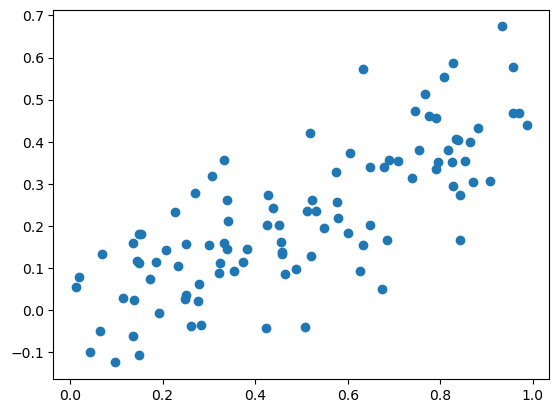

In [11]:
# Plot a scattter plot
plt.scatter(x1,x2);

In [12]:
#(c)
X = MS(['x1', 'x2']).fit_transform(df)  # features
y = df['y']  # target

lm2=sm.OLS(y,X)
lm2.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.198
Method:                 Least Squares   F-statistic:                     13.19
Date:                Sun, 15 Sep 2024   Prob (F-statistic):           8.58e-06
Time:                        23:51:02   Log-Likelihood:                -146.73
No. Observations:                 100   AIC:                             299.5
Df Residuals:                      97   BIC:                             307.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.1639      0.267      8.118      0.000       1.635       2.693
x1             0.1949      0.360      0.541      0.590      -0.520       0.910
x2             3.0498      0.594      5.135      0.000       1.871       4.229
==============================================================================
Omnibus:                        1.800   Durbin-Watson:                   2.170
Prob(Omnibus):                  0.407   Jarque-Bera (JB):                1.254
Skew:                          -0.233   Prob(JB):                        0.534
Kurtosis:                       3.289   Cond. No.                         6.76
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

From the results, $\hat{\beta_{0}}=2.1639$, $\hat{\beta_{1}}=0.1491$, and $\hat{\beta_{2}}=3.0498$. Comparing that to the regression equation $Y=2+2X_{1}+0.3X_{2}+\epsilon$, the estimated coefficients differ from the actual coefficients especially for $\beta_{2}$. 
For the null hypothesis of $H_{0}: \beta_{1}=0$ we fail to reject the null since the p-value associated with the estimated coefficient $(0.590)$ is greater than $0.05$.
For the null hypothesis of $H_{0}: \beta_{2}=0$ we reject the null since the p-value associated with the estimated coefficient $(0.000)$ is less than $0.05$.

In [13]:
# (d)
X = MS(['x1']).fit_transform(df)  # features
y = df['y']  # target

lm3=sm.OLS(y,X)
lm3.fit().summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                  0.008108
Date:                Sun, 15 Sep 2024   Prob (F-statistic):              0.928
Time:                        23:51:02   Log-Likelihood:                -158.75
No. Observations:                 100   AIC:                             321.5
Df Residuals:                      98   BIC:                             326.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      3.0124      0.235     12.836      0.000       2.547       3.478
x1             0.0363      0.403      0.090      0.928      -0.763       0.836
==============================================================================
Omnibus:                        3.370   Durbin-Watson:                   2.074
Prob(Omnibus):                  0.185   Jarque-Bera (JB):                2.720
Skew:                          -0.319   Prob(JB):                        0.257
Kurtosis:                       3.496   Cond. No.                         4.28
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

From the above results in (d), the estimated coefficient is $0.0363$. We fail to reject the null hypothesis of $H_{0}: \beta_{1}=0$ since the estimated p-value of the coefficient is $0.928>0.05$.

In [14]:
# (e)
X = MS(['x2']).fit_transform(df)  # features
y = df['y']  # target

lm4=sm.OLS(y,X)
lm4.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     26.27
Date:                Sun, 15 Sep 2024   Prob (F-statistic):           1.49e-06
Time:                        23:51:02   Log-Likelihood:                -146.88
No. Observations:                 100   AIC:                             297.8
Df Residuals:                      98   BIC:                             303.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.2685      0.183     12.417      0.000       1.906       2.631
x2             3.0223      0.590      5.126      0.000       1.852       4.192
==============================================================================
Omnibus:                        1.898   Durbin-Watson:                   2.153
Prob(Omnibus):                  0.387   Jarque-Bera (JB):                1.363
Skew:                          -0.255   Prob(JB):                        0.506
Kurtosis:                       3.257   Cond. No.                         5.92
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

From the above results in (e), the estimated coefficient is $3.0223$. We can reject the null hypothesis of $H_{0}: \beta_{1}=0$ since the estimated p-value of the coefficient is $0.000<0.05$.

# (f)
The results in (c) and (e) does not contradict each other although they are different. In (c) the coefficient of $X_{2}$ has a high standard error which resulted in a high p-value suggesting that the null hypothesis couldn't be rejected. In (e) however, the coefficient value increase and the standard error reduced which resulted in a high t statistic and a zero p-value which led to us rejecting the null hypothesis. This is an indication that in the presence of $X_{1}$, $X_{2}$ does not provide any additional explanatory power (the two variables are highly correlated).

In [15]:
# (g)

newdata = {'x1': .1, 'x2': .8, 'y': 6} # Create point
df.loc[len(df)] = newdata


In [16]:
# (c)
X = MS(['x1', 'x2']).fit_transform(df)  # features
y = df['y']  # target

lm5=sm.OLS(y,X)
lm5.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     16.20
Date:                Sun, 15 Sep 2024   Prob (F-statistic):           8.34e-07
Time:                        23:51:02   Log-Likelihood:                -148.46
No. Observations:                 101   AIC:                             302.9
Df Residuals:                      98   BIC:                             310.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.1482      0.267      8.048      0.000       1.618       2.678
x1             0.1491      0.359      0.415      0.679      -0.564       0.862
x2             3.2520      0.572      5.686      0.000       2.117       4.387
==============================================================================
Omnibus:                        1.792   Durbin-Watson:                   2.177
Prob(Omnibus):                  0.408   Jarque-Bera (JB):                1.282
Skew:                          -0.250   Prob(JB):                        0.527
Kurtosis:                       3.235   Cond. No.                         6.59
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
# (d)
X = MS(['x1']).fit_transform(df)  # features
y = df['y']  # target

lm6=sm.OLS(y,X)
lm6.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                   0.05493
Date:                Sun, 15 Sep 2024   Prob (F-statistic):              0.815
Time:                        23:51:02   Log-Likelihood:                -162.86
No. Observations:                 101   AIC:                             329.7
Df Residuals:                      99   BIC:                             335.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      3.1077      0.237     13.096      0.000       2.637       3.579
x1            -0.0959      0.409     -0.234      0.815      -0.908       0.716
==============================================================================
Omnibus:                        2.407   Durbin-Watson:                   2.071
Prob(Omnibus):                  0.300   Jarque-Bera (JB):                1.807
Skew:                          -0.231   Prob(JB):                        0.405
Kurtosis:                       3.464   Cond. No.                         4.25
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
# (e)
X = MS(['x2']).fit_transform(df)  # features
y = df['y']  # target

lm7=sm.OLS(y,X)
lm7.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.247
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     32.50
Date:                Sun, 15 Sep 2024   Prob (F-statistic):           1.23e-07
Time:                        23:51:02   Log-Likelihood:                -148.55
No. Observations:                 101   AIC:                             301.1
Df Residuals:                      99   BIC:                             306.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.2297      0.180     12.384      0.000       1.872       2.587
x2             3.2236      0.565      5.701      0.000       2.102       4.346
==============================================================================
Omnibus:                        1.905   Durbin-Watson:                   2.166
Prob(Omnibus):                  0.386   Jarque-Bera (JB):                1.402
Skew:                          -0.267   Prob(JB):                        0.496
Kurtosis:                       3.217   Cond. No.                         5.71
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""